Codes to reproduces figures in 'Search for hyperbolic encounters of compact objects in the third LIGO-Virgo-KAGRA observing run
' Bini et al, 2024, Phys. Rev. D 109, 042009

In [1]:
import io
import sys
import os.path
import ctypes
import ROOT
import numpy as np
import pickle
import pandas as pd
from ROOT import *
from ctypes import *
import string
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
import matplotlib.ticker as ticker
matplotlib.rc('xtick', labelsize=16)
matplotlib.rc('ytick', labelsize=16)
matplotlib.rcParams.update({'font.size': 17})
matplotlib.rcParams['axes.titlesize'] = 14
matplotlib.rcParams['xtick.labelsize'] = 16
matplotlib.rcParams['ytick.labelsize'] = 16
matplotlib.rcParams['legend.fontsize'] = 20

ERROR in cling::CIFactory::createCI(): cannot extract standard library include paths!
Invoking:
  LC_ALL=C x86_64-conda-linux-gnu-c++  -O3 -DNDEBUG -xc++ -E -v /dev/null 2>&1 | sed -n -e '/^.include/,${' -e '/^ \/.*++/p' -e '}'
Results was:
With exit code 0


Welcome to JupyROOT 6.28/10


In [2]:
def readfile(xfile, verbose, mode='waveburst'):
    """
    Read a ROOT file into a pandas DataFrame.

    Parameters:
        xfile   : path to a ROOT file or a .py file containing an 'flist' list of ROOT files
        verbose : if True, print column names
        mode    : 'waveburst'   -> full waveburst tree  [used: ifar, time0, e0, b0, erA9]
                  'waveburst_o' -> reduced waveburst tree [used: snr0, snr1, ff0]
                  'mdc'         -> MDC tree               [used: time0, mass0, mass1, b0]
    """

    np.random.seed(seed=150914)

    # ------------------------------------------------------------------ #
    #  Load the RDataFrame                                                 #
    # ------------------------------------------------------------------ #
    tree_name = 'mdc' if mode == 'mdc' else 'waveburst'

    if xfile.find(".py") == -1:
        df = ROOT.RDataFrame(tree_name, xfile)
    else:
        execfile(xfile, globals())
        print('\nInput file list\n')
        for ifname in flist:
            print(ifname)
            if not os.path.isfile(ifname):
                print("\nError: file", ifname, "doesn't exist")
                exit(1)
        print('\n')
        df = ROOT.RDataFrame(tree_name, flist)

    # ------------------------------------------------------------------ #
    #  Define columns and xvars per mode                                  #
    # ------------------------------------------------------------------ #
    xdf = df

    if mode == 'mdc':
        xdf = xdf.Define('mass0', 'mass[0]')
        xdf = xdf.Define('mass1', 'mass[1]')
        xdf = xdf.Define('b0',    'alpha5')
        xdf = xdf.Define('time0', 'time[0]')

        xvars = ['time0', 'mass0', 'mass1', 'b0']

    elif mode == 'waveburst_o':
        xdf = xdf.Define('snr0', 'snr[0]')
        xdf = xdf.Define('snr1', 'snr[1]')
        xdf = xdf.Define('ff0',  'wf_ff[0]')

        xvars = ['snr0', 'snr1', 'ff0']

    else:  # mode == 'waveburst'
        xdf = xdf.Define('time0', 'time[0]')
        xdf = xdf.Define('e0',    'eBBH[1]')
        xdf = xdf.Define('b0',    'eBBH[2]')
        xdf = xdf.Define('erA9',  'erA[9]')

        xvars = ['time0', 'e0', 'b0', 'erA9']

        xcolNames = xdf.GetColumnNames()
        if verbose:
            print("xgb Colnames:\n{}\n".format(xcolNames))
        if any(var == 'ifar' for var in xcolNames):
            xvars.append('ifar')

    # ------------------------------------------------------------------ #
    #  Convert to pandas                                                   #
    # ------------------------------------------------------------------ #
    xcolNames = xdf.GetColumnNames()
    if verbose:
        print("xgb Colnames:\n{}\n".format(xcolNames))

    xnp = xdf.AsNumpy(columns=xvars)
    xnd = np.vstack([xnp[var] for var in xvars]).T
    xpd = pd.DataFrame(data=xnd, columns=xvars)

    return xpd

### Figure 2

In [3]:
#load cWB results as pandas dataframe

file_2o ='../SIM_xml_v3/overlap/O3b_K99_C01_LH_SIM_flyby_xml3_m2_5_sthr_overlap/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m2_5_sthr_overlap.M1.C_U.V_hvetoLH.C_xgb_cut.root'
df_2o = readfile(file_2o,mode ='waveburst_o',  verbose = False)

file_20o ='../SIM_xml_v3/overlap/O3b_K99_C01_LH_SIM_flyby_xml3_m20_40_sthr_overlap/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m20_40_sthr_overlap.M1.C_U.V_hvetoLH.C_xgb_cut.root'
df_20o = readfile(file_20o,mode ='waveburst_o', verbose=False)

file_80o ='../SIM_xml_v3/overlap/O3b_K99_C01_LH_SIM_flyby_xml3_m80_100_sthr_overlap/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m80_100_sthr_overlap.M1.C_U.V_hvetoLH.C_xgb_cut.root'
df_80o = readfile(file_80o, mode='waveburst_o', verbose = False)

Warning in <TClass::Init>: no dictionary for class detectorParams is available
Warning in <TClass::Init>: no dictionary for class wavearray<double> is available
Error in <TClass::Load>: dictionary of class detector not found
Error in <TClass::Load>: dictionary of class detector not found
Error in <TExMap::Remove>: key 54294 not found at 474
Warning in <TBufferFile::CheckObject>: reference to unavailable class TObject, pointers of this type will be 0
Error in <TClass::Load>: dictionary of class detector not found
Error in <TClass::Load>: dictionary of class detector not found
Error in <TExMap::Remove>: key 62358 not found at 490
Warning in <TBufferFile::CheckObject>: reference to unavailable class TObject, pointers of this type will be 0
Error in <TClass::Load>: dictionary of class detector not found
Error in <TClass::Load>: dictionary of class detector not found
Error in <TExMap::Remove>: key 56358 not found at 23
Warning in <TBufferFile::CheckObject>: reference to unavailable class TO

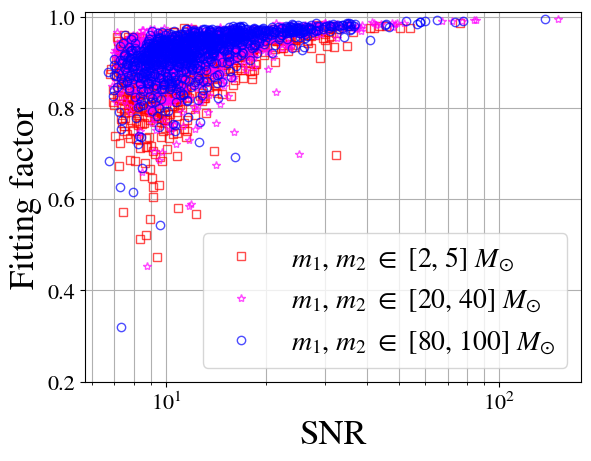

In [4]:
#plot SNR vs Fitting factor for three datasets

plt.plot(np.sqrt(df_2o['snr0']+df_2o['snr1']),df_2o['ff0'],'s',alpha=0.7,color='red', markerfacecolor='none', label='$m_1$, $m_2$ $\in$ [2, 5] $M_{\odot}$')
plt.plot(np.sqrt(df_20o['snr0']+df_20o['snr1']),df_20o['ff0'],'*',alpha=0.7,color='magenta', markerfacecolor='none',label='$m_1$, $m_2$ $\in$ [20, 40] $M_{\odot}$')
plt.plot(np.sqrt(df_80o['snr0']+df_80o['snr1']),df_80o['ff0'],'o',alpha=0.7, color='blue',markerfacecolor='none', label='$m_1$, $m_2$ $\in$ [80, 100] $M_{\odot}$')
plt.legend()
plt.grid()
plt.grid(which='minor')
plt.ylabel('Fitting factor', fontsize=25)
plt.xlabel('SNR', fontsize=25)
plt.xscale('log')
plt.ylim(0.2,1.01)

plt.show()

### Figure 4

In [5]:
def mass_bin (df_mdc_path, df_allsky_path, df_HE_path,v0,rate,title):

    #loads the datasets (simulated and recovered signals using the all-sky XGBoost model and the one trained on hyperbolic encounters (HE))
    mdc = readfile(df_mdc_path, mode='mdc', verbose=False)
    df_HE = readfile(df_HE_path, mode='waveburst', verbose=False)
    df_allsky = readfile(df_allsky_path, mode='waveburst', verbose=False)

    ifar = [1,10,30,50,70,100] #threshold to which compute sensitive volume
    s = 365*24*60*60 #second in one year
    det = []
    
    for i in ifar:
        x = len(df_HE[df_HE['ifar']/s>i])
        det.append(x)
    #print number of signals recovered at IFAR=10years using the all-sky and the HE XGBoost models, and the detection efficiency (number of recovered signals/ injected signals)
    
    print("detected all sky ifar>10: ",len(df_allsky[df_allsky['ifar']/s>10]),np.round(len(df_allsky[df_allsky['ifar']/s>10])/len(mdc),4))
    print("detected HE ifar>10: ",len(df_HE[df_HE['ifar']/s>10]), np.round(len(df_HE[df_HE['ifar']/s>10])/len(mdc),4))
    eff10yr = len(df_HE[df_HE['ifar']/s>10])/len(mdc)
    det10yr = len(df_HE[df_HE['ifar']/s>10])
    
    V = v0*rate*np.array(det)/len(mdc) #SENSITIVITY VOLUME
    
    #plot sensitivity vs ifar
    fig = plt.figure()#
    plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    plt.plot(ifar, V, '.',color='blue',markersize=15)
    plt.ylabel('Sensitivity volume\n$[\mathrm{Gpc}^3 $ year]', fontsize=24)
    plt.xlabel("IFAR [years]", fontsize=24)
    plt.grid('on')
    plt.show()

    return eff10yr, det10yr


detected all sky ifar>10:  1357 0.0905
detected HE ifar>10:  2365 0.1577


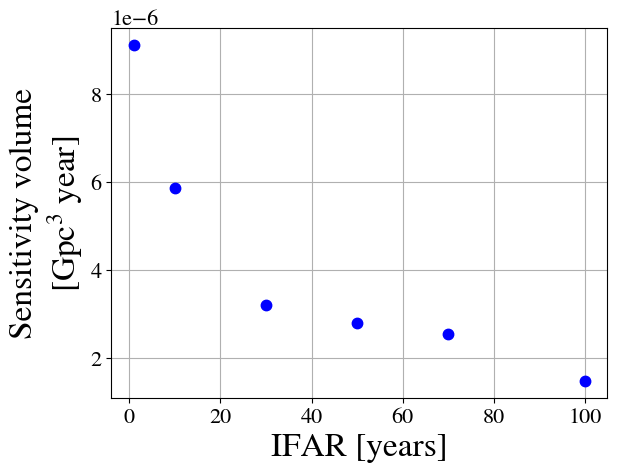

detected all sky ifar>10:  1720 0.1146
detected HE ifar>10:  2736 0.1823


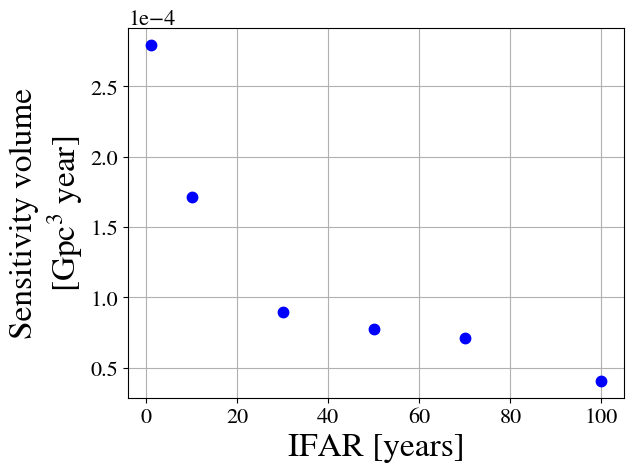

detected all sky ifar>10:  2614 0.1743
detected HE ifar>10:  3435 0.229


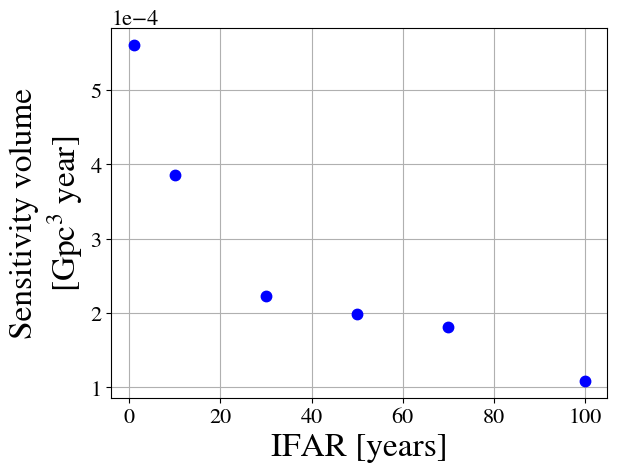

detected all sky ifar>10:  2685 0.179
detected HE ifar>10:  3604 0.2403


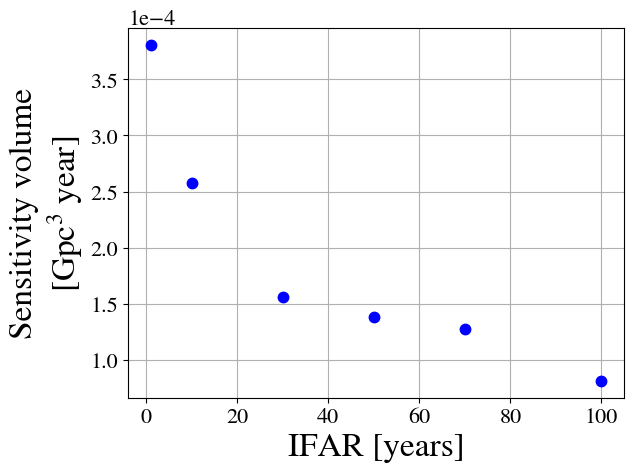

detected all sky ifar>10:  2331 0.1556
detected HE ifar>10:  3278 0.2188


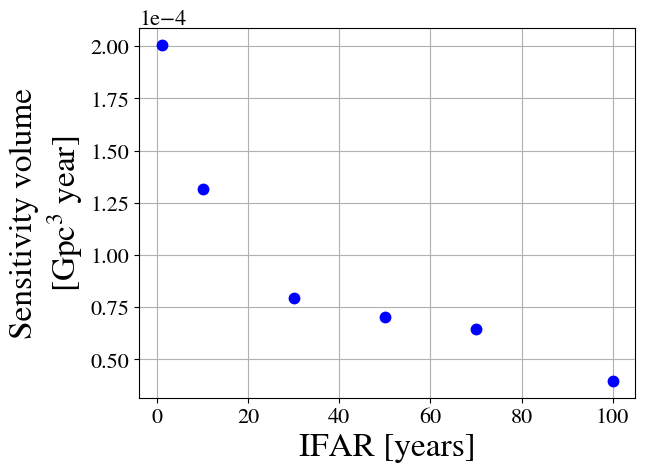

detected all sky ifar>10:  2102 0.1402
detected HE ifar>10:  2995 0.1998


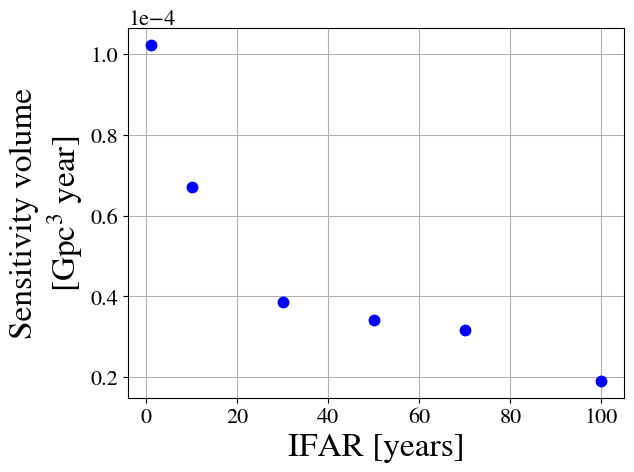

In [6]:
# Load cWB injections at different mass ranges and compute sensitivity volume vs IFAR and effieciency as IFAR=10 years
#2 5 
df_mdc_path="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m2_5_sthr/merge/mdc_O3b_K99_C01_LH_SIM_flyby_xml3_m2_5_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.root"
df_allsky_path="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m2_5_sthr/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m2_5_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.XGB_rthr0_tst10_v11f_O3b.S_o3b_ifar.root"
df_HE_path="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m2_5_sthr/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m2_5_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.XGB_rthr0_HE_O3b_as3.S_ifar.root"

rate = 0.00219666
v0 = 0.0168929

eff10_m2_5, det10_m2_5 = mass_bin(df_mdc_path,df_allsky_path,df_HE_path, v0, rate,title='$[2, 5] \ M_{\odot}$' )

#5 20 
df_mdc_path="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m5_20_sthr/merge/mdc_O3b_K99_C01_LH_SIM_flyby_xml3_m5_20_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.root"
df_allsky_path="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m5_20_sthr/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m5_20_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.XGB_rthr0_tst10_v11f_O3b.S_o3b_ifar.root"
df_HE_path="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m5_20_sthr/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m5_20_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.XGB_rthr0_HE_O3b_as3.S_ifar.root"

rate = 0.00746478
v0 = 0.125876

eff10_m5_20, det10_m5_20 = mass_bin(df_mdc_path,df_allsky_path,df_HE_path, v0, rate ,title='$[5, 20] \ M_{\odot}$')

#20 40 
df_mdc_path="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m20_40_sthr/merge/mdc_O3b_K99_C01_LH_SIM_flyby_xml3_m20_40_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.root"
df_allsky_path="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m20_40_sthr/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m20_40_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.XGB_rthr0_tst10_v11f_O3b.S_o3b_ifar.root"
df_HE_path="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m20_40_sthr/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m20_40_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.XGB_rthr0_HE_O3b_as3.S_ifar.root"

rate = 0.0133608
v0 = 0.125876

eff10_m20_40, det10_m20_40 = mass_bin(df_mdc_path,df_allsky_path,df_HE_path, v0, rate , title='$[20, 40] \ M_{\odot}$')

#40 60 
df_mdc_path="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m40_60_sthr/merge/mdc_O3b_K99_C01_LH_SIM_flyby_xml3_m40_60_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.root"
df_allsky_path="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m40_60_sthr/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m40_60_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.XGB_rthr0_tst10_v11f_O3b.S_o3b_ifar.root"
df_HE_path="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m40_60_sthr/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m40_60_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.XGB_rthr0_HE_O3b_as3.S_ifar.root"

rate = 0.00852574
v0 = 0.125876

eff10_m40_60, det10_m40_60 = mass_bin(df_mdc_path,df_allsky_path,df_HE_path, v0, rate , title='$[40, 60] \ M_{\odot}$')


#60 80 
df_mdc_path="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m60_80_sthr/merge/mdc_O3b_K99_C01_LH_SIM_flyby_xml3_m60_80_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.root"
df_allsky_path="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m60_80_sthr/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m60_80_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.XGB_rthr0_tst10_v11f_O3b.S_o3b_ifar.root"
df_HE_path="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m60_80_sthr/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m60_80_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.XGB_rthr0_HE_O3b_as3.S_ifar.root"

rate = 0.00478508
v0 = 0.125876

eff10_m60_80, det10_m60_80= mass_bin(df_mdc_path,df_allsky_path,df_HE_path, v0, rate, title = '$[60, 80] \ M_{\odot}$' )

#80 100 
df_mdc_path="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m80_100_sthr/merge/mdc_O3b_K99_C01_LH_SIM_flyby_xml3_m80_100_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.root"
df_allsky_path="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m80_100_sthr/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m80_100_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.XGB_rthr0_tst10_v11f_O3b.S_o3b_ifar.root"
df_HE_path="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m80_100_sthr/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m80_100_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.XGB_rthr0_HE_O3b_as3.S_ifar.root"

rate = 0.00266636
v0 = 0.125876

eff10_m80_100, det10_m80_100 = mass_bin(df_mdc_path,df_allsky_path,df_HE_path, v0, rate ,title='$[80, 100] \ M_{\odot}$')


In [7]:
#injections volume
v = 0.125876 #z = 0.1 O3b
v=[v]*5
v2_5 = [0.0168929] #per 2 - 5 mass
V= np.array(np.concatenate((v2_5,v))) 

#acceptance rate
R =[0.00219666,0.00746478,0.0133608,0.00852574,0.00478508,0.00266636]

#cWB efficiencies IFAR>10 model-informed (hyperbolic encounter XGBoost model)
eff = (eff10_m2_5, eff10_m5_20, eff10_m20_40 , eff10_m40_60 , eff10_m60_80 , eff10_m80_100) 

# mass ranges
m = ['2-5','5-20','20-40','40-60','60-80','80-100'] 

#copmute sensitive volume
v_astro = V*np.array(R)*np.array(eff)
print('SENSITIVE VOLUME ',v_astro)

#number of detected events by CWB with IFAR>10years
detected = (det10_m2_5, det10_m5_20,det10_m20_40, det10_m40_60, det10_m60_80, det10_m80_100) 

#error bars
yerr_stat = 1/(np.sqrt(detected))*v_astro #statistical error very low <2%
yerr_cal = 3*0.12*v_astro #calibration error is 12% on distance, i.e. 3*12% in volume
yerr = np.sqrt(yerr_stat**2+yerr_cal**2)

print('Statistical error on volume: ',yerr_stat)
print('Calibration error: ', yerr_cal)
print('Total error: ',yerr)

SENSITIVE VOLUME  [5.85341960e-06 1.71264131e-04 3.85210172e-04 2.57919613e-04
 1.31777816e-04 6.70455573e-05]
Statistical error on volume:  [1.20363300e-07 3.27422385e-06 6.57255722e-06 4.29627406e-06
 2.30164231e-06 1.22510015e-06]
Calibration error:  [2.10723105e-06 6.16550871e-05 1.38675662e-04 9.28510607e-05
 4.74400139e-05 2.41364006e-05]
Total error:  [2.11066578e-06 6.17419655e-05 1.38831328e-04 9.29504032e-05
 4.74958153e-05 2.41674721e-05]


(2000.0, 1000000.0)

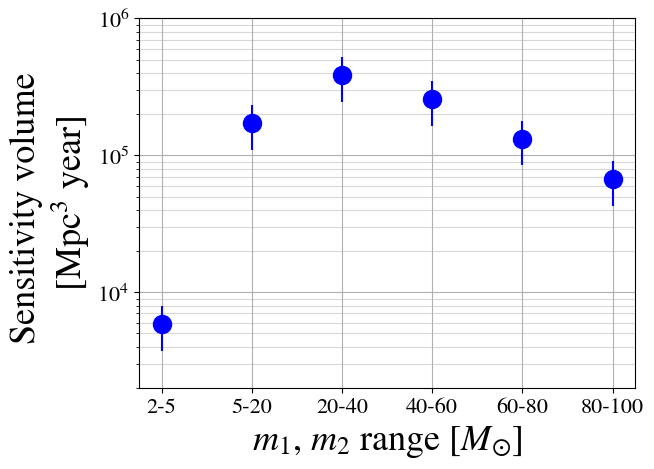

In [8]:
fig = plt.figure()
plt.ticklabel_format(axis='both', style='sci', scilimits=(0,0))
plt.errorbar(m , v_astro*1e9,yerr = yerr*1e9,fmt='o', color='blue', markersize=13)#, label='redshift = 0.1')
plt.ylabel('Sensitivity volume \n$[\mathrm{Mpc}^3 $ year]', fontsize=26)
plt.xlabel(r'$m_1$, $m_2$ range $[M_{\odot}]$',fontsize=26)
plt.grid(which='minor', alpha=0.5)
plt.grid('on')
plt.yscale('log')
plt.ylim(2e3,1e6)
#plt.savefig('SensitivityV_err.png', bbox_inches="tight", trasparent = 'true')

### Figure 5

In [9]:
# model informed
mdc_m2="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m2_5_sthr/merge/mdc_O3b_K99_C01_LH_SIM_flyby_xml3_m2_5_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.root"
df_m2_HE="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m2_5_sthr/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m2_5_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.XGB_rthr0_HE_O3b_as3.S_ifar.root"

mdc_m5="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m5_20_sthr/merge/mdc_O3b_K99_C01_LH_SIM_flyby_xml3_m5_20_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.root"
df_m5_HE="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m5_20_sthr/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m5_20_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.XGB_rthr0_HE_O3b_as3.S_ifar.root"

mdc_m20="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m20_40_sthr/merge/mdc_O3b_K99_C01_LH_SIM_flyby_xml3_m20_40_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.root"
df_m20_HE="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m20_40_sthr/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m20_40_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.XGB_rthr0_HE_O3b_as3.S_ifar.root"

mdc_m40="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m40_60_sthr/merge/mdc_O3b_K99_C01_LH_SIM_flyby_xml3_m40_60_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.root"
df_m40_HE="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m40_60_sthr/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m40_60_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.XGB_rthr0_HE_O3b_as3.S_ifar.root"

mdc_m60="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m60_80_sthr/merge/mdc_O3b_K99_C01_LH_SIM_flyby_xml3_m60_80_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.root"
df_m60_HE="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m60_80_sthr/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m60_80_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.XGB_rthr0_HE_O3b_as3.S_ifar.root"

mdc_m80="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m80_100_sthr/merge/mdc_O3b_K99_C01_LH_SIM_flyby_xml3_m80_100_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.root"
df_m80_HE="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m80_100_sthr/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m80_100_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.XGB_rthr0_HE_O3b_as3.S_ifar.root"

def plott(df,mrange):
    #plot eccentricity versus impact parameter
    
    s = 365*24*60*60 #seconds in year
    df = df[df['ifar']/s>10]
    C = 6.7e-11*2e30*(df['mass1']+df['mass0'])/(3e8**2)
    
    plt.hist2d(df['e0'], df['b0_y']/C,bins=50,range=[[1.05,1.6],[60,100]], norm=matplotlib.colors.LogNorm(vmin=1, vmax=300), cmap='coolwarm')
    plt.title(mrange)    
    plt.grid(which='minor')
    
def df_mdc_merge(df, mdc):
    #merge dataframe simulated and recovered signals
    
    df = readfile(df, mode='waveburst', verbose = False)
    mdc = readfile(mdc,mode = 'mdc' , verbose = False)
    df['Ref_gps'] =np.array(df['time0'].astype(int))
    mdc['Ref_gps'] = np.array(mdc['time0'].astype(int))
    m = pd.merge(df, mdc, on='Ref_gps')
    return m

m2_HE = df_mdc_merge(df_m2_HE, mdc_m2)
m5_HE = df_mdc_merge(df_m5_HE, mdc_m5)
m20_HE = df_mdc_merge(df_m20_HE, mdc_m20)
m40_HE = df_mdc_merge(df_m40_HE, mdc_m40)
m60_HE = df_mdc_merge(df_m60_HE, mdc_m60)
m80_HE = df_mdc_merge(df_m80_HE, mdc_m80)

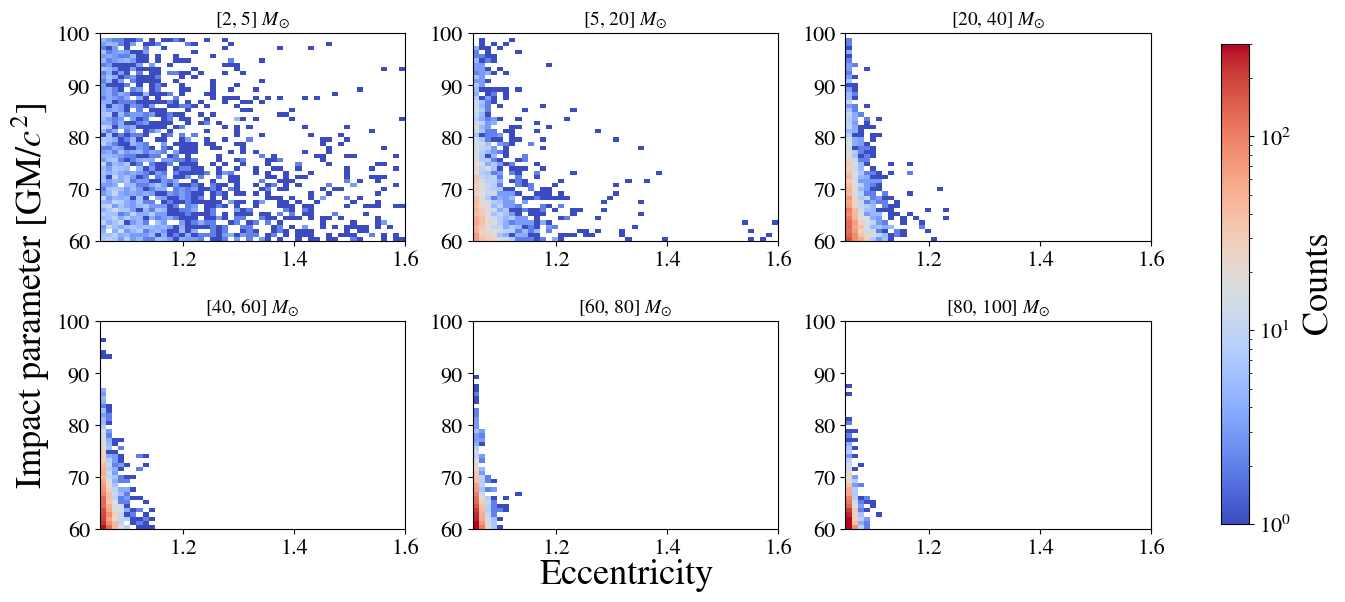

In [10]:
fig = plt.figure(figsize=(14,6))
plt.subplot(2,3,1)
plott(m2_HE,'[2, 5] $M_{\odot}$')
plt.subplot(2,3,2)
plott(m5_HE,'[5, 20] $M_{\odot}$')
plt.subplot(2,3,3)
plott(m20_HE,'[20, 40] $M_{\odot}$')
plt.subplot(2,3,4)
plott(m40_HE,'[40, 60] $M_{\odot}$')
plt.subplot(2,3,5)
plott(m60_HE,'[60, 80] $M_{\odot}$')
plt.subplot(2,3,6)
plott(m80_HE,'[80, 100] $M_{\odot}$')
plt.tight_layout()
plt.gcf().text(0.425,0.0,"Eccentricity", ha="center",fontsize=26)
plt.gcf().text(0,0.176,"Impact parameter [GM/$c^2$]", ha="center", rotation =90, fontsize=26)
plt.gcf().text(0.92,0.43,"Counts", ha="center", rotation =90, fontsize=26)

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.1, 0.02, 0.8])
cbar =plt.colorbar(cax=cbar_ax)
plt.show()

### Figure 6

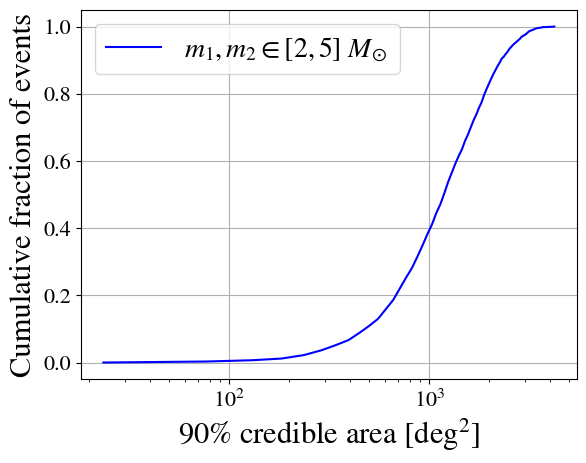

In [11]:
#load dataset
mdc_m2="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m2_5_sthr/merge/mdc_O3b_K99_C01_LH_SIM_flyby_xml3_m2_5_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.root"
df_m2_HE="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m2_5_sthr/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m2_5_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.XGB_rthr0_HE_O3b_as3.S_ifar.root"
m2 = readfile(df_m2_HE, mode='waveburst', verbose=False)
mdc2 = readfile(mdc_m2,mode='mdc', verbose=False)

mdc_m20="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m20_40_sthr/merge/mdc_O3b_K99_C01_LH_SIM_flyby_xml3_m20_40_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.root"
df_m20_HE="../SIM_xml_v3/O3b_K99_C01_LH_SIM_flyby_xml3_m20_40_sthr/merge/wave_O3b_K99_C01_LH_SIM_flyby_xml3_m20_40_sthr.M1.C_U.V_hvetoLH.C_xgb_cut.X_Test_F25.XGB_rthr0_HE_O3b_as3.S_ifar.root"
m20 = readfile(df_m20_HE, mode='waveburst', verbose=False)
mdc20 = readfile(mdc_m20,mode='mdc', verbose=False)

s = 365*24*60*60 #seconds in one year

#select signals recovered with IFAR>10yr
m2_b=m2[m2['ifar']/s>10]
values2, base2 = np.histogram(m2_b['erA9']**2, bins=80)
cumulative2 = np.cumsum(values2)

#plot 90% credible area
plt.plot(base2[:-1],cumulative2/len(m2_b), color='blue', label='$m_1, m_2 \in [2, 5] \ M_{\odot}$ ')
plt.xlabel('90% credible area [deg$^2$]', fontsize=22)
plt.ylabel('Cumulative fraction of events', fontsize=22)
plt.xscale('log')
plt.legend()
plt.grid('on')
plt.show()
